# Chicago crash data EDA

Goal:
- Check whether the three crash datasets can support a route-level crash-risk model.
- Separate usable pre-crash signals from post-crash leakage fields.
- Produce a light EDA that is safe to rerun on large CSVs.

Note:
- These files are large, so the notebook uses chunked summaries for full-table checks and a sample for plots.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

SEED = 7
np.random.seed(SEED)

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "crisp_stages").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root")

ROOT = find_repo_root(Path.cwd())
DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "figures" / "stage2"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CRASHES = DATA_DIR / "Traffic_Crashes_-_Crashes.csv"
VEHICLES = DATA_DIR / "Traffic_Crashes_-_Vehicles.csv"
PEOPLE = DATA_DIR / "Traffic_Crashes_-_People.csv"

CRASH_DATE_FMT = "%m/%d/%Y %I:%M:%S %p"
CHUNKSIZE = 100_000

def save_figure(fig: plt.Figure, name: str) -> Path:
    path = FIGURE_DIR / f"{name}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    return path


In [2]:
def summarize_file(path, usecols, *, cat_cols=(), numeric_cols=(), date_cols=(), chunksize=CHUNKSIZE):
    rows = 0
    missing = Counter()
    top_values = {col: Counter() for col in cat_cols}
    numeric_values = {col: [] for col in numeric_cols}
    date_bounds = {col: {"min": None, "max": None} for col in date_cols}

    for chunk in pd.read_csv(path, usecols=usecols, chunksize=chunksize, low_memory=False):
        rows += len(chunk)
        for col in usecols:
            missing[col] += chunk[col].isna().sum()

        for col in date_cols:
            parsed = pd.to_datetime(chunk[col], format=CRASH_DATE_FMT, errors="coerce")
            cmin = parsed.min()
            cmax = parsed.max()
            if pd.notna(cmin) and (date_bounds[col]["min"] is None or cmin < date_bounds[col]["min"]):
                date_bounds[col]["min"] = cmin
            if pd.notna(cmax) and (date_bounds[col]["max"] is None or cmax > date_bounds[col]["max"]):
                date_bounds[col]["max"] = cmax

        for col in cat_cols:
            top_values[col].update(chunk[col].dropna().astype(str).value_counts().to_dict())

        for col in numeric_cols:
            numeric_values[col].append(pd.to_numeric(chunk[col], errors="coerce"))

    numeric_stats = {}
    for col, parts in numeric_values.items():
        series = pd.concat(parts, ignore_index=True)
        numeric_stats[col] = {
            "min": float(series.min()),
            "median": float(series.median()),
            "mean": float(series.mean()),
            "max": float(series.max()),
        }

    return {
        "rows": rows,
        "missing": missing,
        "top_values": top_values,
        "numeric": numeric_stats,
        "date_bounds": date_bounds,
    }


def top_table(counter: Counter, n: int = 8) -> pd.DataFrame:
    return pd.DataFrame(counter.most_common(n), columns=["value", "count"])


def format_percent(count: int, rows: int) -> str:
    return f"{(count / rows * 100):.2f}" if rows else "0.00"


def format_frequency(count: int, rows: int) -> str:
    return f"{count:,} ({format_percent(count, rows)}%)"


def format_numeric_summary(stats: dict[str, float]) -> str:
    return (
        f"min {stats['min']:.2f}, median {stats['median']:.2f}, "
        f"mean {stats['mean']:.2f}, max {stats['max']:.2f}"
    )


def format_date_summary(bounds: dict[str, pd.Timestamp | None]) -> str:
    if bounds["min"] is None or bounds["max"] is None:
        return "n/a"
    return f"{bounds['min']} to {bounds['max']}"


def format_top_summary(counter: Counter) -> str:
    if not counter:
        return "n/a"
    value, count = counter.most_common(1)[0]
    return f"{value} ({count:,})"


def build_profile_table(stats: dict, specs: list[dict[str, str]]) -> pd.DataFrame:
    rows = []
    for spec in specs:
        field = spec["field"]
        summary_kind = spec["summary"]
        if summary_kind == "numeric":
            summary = format_numeric_summary(stats["numeric"][field])
        elif summary_kind == "date":
            summary = format_date_summary(stats["date_bounds"][field])
        else:
            summary = format_top_summary(stats["top_values"][field])
        rows.append(
            {
                "field": field,
                "role": spec["role"],
                "dtype": spec["dtype"],
                "missing %": float(format_percent(stats["missing"][field], stats["rows"])),
                "summary stats": summary,
            }
        )
    return pd.DataFrame(rows)


def count_columns(path: Path) -> int:
    return len(pd.read_csv(path, nrows=0, low_memory=False).columns)


def count_zero_coordinates(path: Path, chunksize: int = CHUNKSIZE) -> int:
    total = 0
    for chunk in pd.read_csv(path, usecols=["LATITUDE", "LONGITUDE"], chunksize=chunksize, low_memory=False):
        lat = pd.to_numeric(chunk["LATITUDE"], errors="coerce")
        lon = pd.to_numeric(chunk["LONGITUDE"], errors="coerce")
        total += int(((lat == 0) | (lon == 0)).sum())
    return total


def count_invalid_age(path: Path, chunksize: int = CHUNKSIZE) -> int:
    total = 0
    for chunk in pd.read_csv(path, usecols=["AGE"], chunksize=chunksize, low_memory=False):
        age = pd.to_numeric(chunk["AGE"], errors="coerce")
        total += int((age.notna() & ~age.between(0, 110)).sum())
    return total


def count_outside_window(path: Path, start_year: int, end_year: int, chunksize: int = CHUNKSIZE) -> int:
    total = 0
    for chunk in pd.read_csv(path, usecols=["CRASH_DATE"], chunksize=chunksize, low_memory=False):
        crash_ts = pd.to_datetime(chunk["CRASH_DATE"], format=CRASH_DATE_FMT, errors="coerce")
        years = crash_ts.dt.year
        total += int((years.notna() & ~years.between(start_year, end_year)).sum())
    return total


## 1) Crash table overview

This table should be the main training set for a pre-crash probability model because it has:
- time
- location
- weather and road conditions
- speed limit and road type

Many of the remaining fields are outcomes or police annotations and should not be used as route-time predictors.

In [3]:
crash_usecols = [
    "CRASH_DATE",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "LATITUDE",
    "LONGITUDE",
    "POSTED_SPEED_LIMIT",
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFIC_CONTROL_DEVICE",
    "TRAFFICWAY_TYPE",
    "INTERSECTION_RELATED_I",
    "WORK_ZONE_I",
    "ROAD_DEFECT",
    "PRIM_CONTRIBUTORY_CAUSE",
    "FIRST_CRASH_TYPE",
    "CRASH_TYPE",
    "MOST_SEVERE_INJURY",
    "INJURIES_TOTAL",
]

crash_cat_cols = [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFIC_CONTROL_DEVICE",
    "TRAFFICWAY_TYPE",
    "INTERSECTION_RELATED_I",
    "WORK_ZONE_I",
    "ROAD_DEFECT",
    "PRIM_CONTRIBUTORY_CAUSE",
    "FIRST_CRASH_TYPE",
    "CRASH_TYPE",
    "MOST_SEVERE_INJURY",
]

crash_stats = summarize_file(
    CRASHES,
    crash_usecols,
    cat_cols=crash_cat_cols,
    numeric_cols=["CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH", "LATITUDE", "LONGITUDE", "POSTED_SPEED_LIMIT"],
    date_cols=["CRASH_DATE"],
)

crash_profile_specs = [
    {"field": "CRASH_DATE", "role": "crash timestamp", "dtype": "datetime", "summary": "date"},
    {"field": "CRASH_HOUR", "role": "hour-of-day context", "dtype": "integer", "summary": "numeric"},
    {"field": "CRASH_DAY_OF_WEEK", "role": "weekly context", "dtype": "integer", "summary": "numeric"},
    {"field": "LATITUDE", "role": "spatial position", "dtype": "numeric", "summary": "numeric"},
    {"field": "LONGITUDE", "role": "spatial position", "dtype": "numeric", "summary": "numeric"},
    {"field": "POSTED_SPEED_LIMIT", "role": "road-speed context", "dtype": "numeric", "summary": "numeric"},
    {"field": "WEATHER_CONDITION", "role": "environment", "dtype": "categorical", "summary": "categorical"},
    {"field": "LIGHTING_CONDITION", "role": "visibility", "dtype": "categorical", "summary": "categorical"},
]

crash_profile = build_profile_table(crash_stats, crash_profile_specs)
crash_quality = pd.DataFrame(
    {
        "column": crash_usecols,
        "missing %": [float(format_percent(crash_stats["missing"][col], crash_stats["rows"])) for col in crash_usecols],
    }
).sort_values("missing %", ascending=False)

display(crash_profile)
display(crash_quality)
print(f'Rows: {crash_stats["rows"]:,}')
print("CRASH_DATE range:", format_date_summary(crash_stats["date_bounds"]["CRASH_DATE"]))

for col in [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFIC_CONTROL_DEVICE",
    "TRAFFICWAY_TYPE",
    "PRIM_CONTRIBUTORY_CAUSE",
    "FIRST_CRASH_TYPE",
    "CRASH_TYPE",
    "MOST_SEVERE_INJURY",
]:
    print(f"\nTop values for {col}")
    display(top_table(crash_stats["top_values"][col], 8))


,field,role,dtype,missing %,summary stats
0,CRASH_DATE,crash timestamp,datetime,0.00,2013-03-03 16:48:00 to 2026-04-13 02:27:00
1,CRASH_HOUR,hour-of-day context,integer,0.00,"min 0.00, median 14.00, mean 13.19, max 23.00"
2,CRASH_DAY_OF_WEEK,weekly context,integer,0.00,"min 1.00, median 4.00, mean 4.12, max 7.00"
3,LATITUDE,spatial position,numeric,0.77,"min 0.00, median 41.88, mean 41.86, max 42.02"
4,LONGITUDE,spatial position,numeric,0.77,"min -87.94, median -87.67, mean -87.67, max 0.00"
5,POSTED_SPEED_LIMIT,road-speed context,numeric,0.00,"min 0.00, median 30.00, mean 28.42, max 99.00"
6,WEATHER_CONDITION,environment,categorical,0.00,"CLEAR (818,876)"
7,LIGHTING_CONDITION,visibility,categorical,0.00,"DAYLIGHT (668,913)"


,column,missing %
13,WORK_ZONE_I,99.46
12,INTERSECTION_RELATED_I,76.99
4,LATITUDE,0.77
5,LONGITUDE,0.77
19,INJURIES_TOTAL,0.22
18,MOST_SEVERE_INJURY,0.22
11,TRAFFICWAY_TYPE,0.00
17,CRASH_TYPE,0.00
16,FIRST_CRASH_TYPE,0.00
15,PRIM_CONTRIBUTORY_CAUSE,0.00


Rows: 1,045,043
CRASH_DATE range: 2013-03-03 16:48:00 to 2026-04-13 02:27:00

Top values for WEATHER_CONDITION


,value,count
0,CLEAR,818876
1,RAIN,87129
2,UNKNOWN,63630
3,SNOW,35098
4,CLOUDY/OVERCAST,30751
5,OTHER,3444
6,FREEZING RAIN/DRIZZLE,2547
7,FOG/SMOKE/HAZE,1508



Top values for LIGHTING_CONDITION


...

,value,count
0,PARKED MOTOR VEHICLE,240637
1,REAR END,227921
2,SIDESWIPE SAME DIRECTION,162769
3,TURNING,151142
4,ANGLE,113373
5,FIXED OBJECT,47888
6,PEDESTRIAN,25133
7,PEDALCYCLIST,17162



Top values for CRASH_TYPE


,value,count
0,NO INJURY / DRIVE AWAY,762073
1,INJURY AND / OR TOW DUE TO CRASH,282970



Top values for MOST_SEVERE_INJURY


,value,count
0,NO INDICATION OF INJURY,892970
1,NONINCAPACITATING INJURY,83379
2,"REPORTED, NOT EVIDENT",48422
3,INCAPACITATING INJURY,16901
4,FATAL,1099


In [4]:
feature_map = pd.DataFrame(
    [
        ["Pre-crash / usable", "CRASH_DATE", "Time-of-day and seasonality"],
        ["Pre-crash / usable", "CRASH_HOUR / CRASH_DAY_OF_WEEK / CRASH_MONTH", "Temporal context"],
        ["Pre-crash / usable", "LATITUDE / LONGITUDE", "Spatial risk surface"],
        ["Pre-crash / usable", "POSTED_SPEED_LIMIT", "Road design context"],
        ["Pre-crash / usable", "WEATHER_CONDITION / LIGHTING_CONDITION / ROADWAY_SURFACE_COND", "Environment at the time"],
        ["Pre-crash / usable", "TRAFFICWAY_TYPE / LANE_CNT / ALIGNMENT / ROAD_DEFECT / WORK_ZONE_I", "Road geometry and state"],
        ["Post-crash leakage", "CRASH_TYPE / FIRST_CRASH_TYPE / MOST_SEVERE_INJURY / INJURIES_*", "Known after the event"],
        ["Post-crash leakage", "PRIM_CONTRIBUTORY_CAUSE / SEC_CONTRIBUTORY_CAUSE", "Police attribution after the crash"],
        ["Secondary only", "VEHICLES and PEOPLE tables", "Useful for severity and composition, not direct route risk"],
    ],
    columns=["bucket", "field", "why"],
)

display(feature_map)


,bucket,field,why
0,Pre-crash / usable,CRASH_DATE,Time-of-day and seasonality
1,Pre-crash / usable,CRASH_HOUR / CRASH_DAY_OF_WEEK / CRASH_MONTH,Temporal context
2,Pre-crash / usable,LATITUDE / LONGITUDE,Spatial risk surface
3,Pre-crash / usable,POSTED_SPEED_LIMIT,Road design context
4,Pre-crash / usable,WEATHER_CONDITION / LIGHTING_CONDITION / ROADW...,Environment at the time
5,Pre-crash / usable,TRAFFICWAY_TYPE / LANE_CNT / ALIGNMENT / ROAD_...,Road geometry and state
6,Post-crash leakage,CRASH_TYPE / FIRST_CRASH_TYPE / MOST_SEVERE_IN...,Known after the event
7,Post-crash leakage,PRIM_CONTRIBUTORY_CAUSE / SEC_CONTRIBUTORY_CAUSE,Police attribution after the crash
8,Secondary only,VEHICLES and PEOPLE tables,"Useful for severity and composition, not direc..."


## Helpful features for route-risk modeling

Use these as the main feature set for a crash-risk route planner:

- `CRASH_DATE`
- `CRASH_HOUR`
- `CRASH_DAY_OF_WEEK`
- `CRASH_MONTH`
- `LATITUDE`
- `LONGITUDE`
- `POSTED_SPEED_LIMIT`
- `WEATHER_CONDITION`
- `LIGHTING_CONDITION`
- `ROADWAY_SURFACE_COND`
- `TRAFFIC_CONTROL_DEVICE`
- `DEVICE_CONDITION`
- `TRAFFICWAY_TYPE`
- `LANE_CNT`
- `ALIGNMENT`
- `ROAD_DEFECT`
- `INTERSECTION_RELATED_I`
- `WORK_ZONE_I`
- `WORK_ZONE_TYPE`
- `WORKERS_PRESENT_I`

Useful only as derived or secondary features:

- road segment / grid cell ID from coordinates
- distance to nearest intersection
- rush-hour flag
- weekend flag
- historical crash density in nearby cells
- rolling crash counts by segment and time window

Avoid using these as direct predictors because they leak post-crash information:

- `CRASH_TYPE`
- `FIRST_CRASH_TYPE`
- `PRIM_CONTRIBUTORY_CAUSE`
- `SEC_CONTRIBUTORY_CAUSE`
- `MOST_SEVERE_INJURY`
- `INJURIES_TOTAL`
- `INJURIES_FATAL`
- `INJURIES_INCAPACITATING`
- `INJURIES_NON_INCAPACITATING`
- `INJURIES_REPORTED_NOT_EVIDENT`
- `INJURIES_NO_INDICATION`
- `INJURIES_UNKNOWN`


## Feature selection table

| Group | Use for model? | Examples |
| --- | --- | --- |
| Safe predictors | Yes | `CRASH_DATE`, `CRASH_HOUR`, `CRASH_DAY_OF_WEEK`, `CRASH_MONTH`, `LATITUDE`, `LONGITUDE`, `POSTED_SPEED_LIMIT`, `WEATHER_CONDITION`, `LIGHTING_CONDITION`, `ROADWAY_SURFACE_COND`, `TRAFFIC_CONTROL_DEVICE`, `DEVICE_CONDITION`, `TRAFFICWAY_TYPE`, `LANE_CNT`, `ALIGNMENT`, `ROAD_DEFECT`, `INTERSECTION_RELATED_I`, `WORK_ZONE_I`, `WORK_ZONE_TYPE`, `WORKERS_PRESENT_I` |
| Derived features | Yes, if engineered from safe predictors | road segment ID, grid cell ID, distance to nearest intersection, rush-hour flag, weekend flag, historical crash density, rolling crash counts |
| Leakage fields | No | `CRASH_TYPE`, `FIRST_CRASH_TYPE`, `PRIM_CONTRIBUTORY_CAUSE`, `SEC_CONTRIBUTORY_CAUSE`, `MOST_SEVERE_INJURY`, `INJURIES_TOTAL`, `INJURIES_FATAL`, `INJURIES_INCAPACITATING`, `INJURIES_NON_INCAPACITATING`, `INJURIES_REPORTED_NOT_EVIDENT`, `INJURIES_NO_INDICATION`, `INJURIES_UNKNOWN` |


## 2) Vehicles and people tables

These tables are useful mainly as secondary analysis:
- vehicle mix and maneuver patterns
- who was involved and how badly they were hurt
- validation of crash composition

They are not the best direct input for a route planner because they describe what happened after the crash.

In [5]:
vehicle_usecols = ["UNIT_TYPE", "VEHICLE_TYPE", "MANEUVER", "TRAVEL_DIRECTION", "OCCUPANT_CNT", "EXCEED_SPEED_LIMIT_I"]
vehicle_stats = summarize_file(
    VEHICLES,
    vehicle_usecols,
    cat_cols=["UNIT_TYPE", "VEHICLE_TYPE", "MANEUVER", "TRAVEL_DIRECTION", "EXCEED_SPEED_LIMIT_I"],
    numeric_cols=["OCCUPANT_CNT"],
)

people_usecols = [
    "PERSON_TYPE",
    "INJURY_CLASSIFICATION",
    "SEX",
    "AGE",
    "DRIVER_ACTION",
    "DRIVER_VISION",
    "PHYSICAL_CONDITION",
    "SAFETY_EQUIPMENT",
    "AIRBAG_DEPLOYED",
]
people_stats = summarize_file(
    PEOPLE,
    people_usecols,
    cat_cols=[
        "PERSON_TYPE",
        "INJURY_CLASSIFICATION",
        "SEX",
        "DRIVER_ACTION",
        "DRIVER_VISION",
        "PHYSICAL_CONDITION",
        "SAFETY_EQUIPMENT",
        "AIRBAG_DEPLOYED",
    ],
    numeric_cols=["AGE"],
)

dataset_overview = pd.DataFrame(
    [
        {
            "dataset": "Crashes",
            "rows": crash_stats["rows"],
            "columns": count_columns(CRASHES),
            "key fields": "CRASH_DATE, LATITUDE, LONGITUDE, POSTED_SPEED_LIMIT, WEATHER_CONDITION",
            "time coverage": format_date_summary(crash_stats["date_bounds"]["CRASH_DATE"]),
        },
        {
            "dataset": "Vehicles",
            "rows": vehicle_stats["rows"],
            "columns": count_columns(VEHICLES),
            "key fields": "CRASH_RECORD_ID, UNIT_TYPE, VEHICLE_TYPE, MANEUVER, OCCUPANT_CNT",
            "time coverage": "linked to crash dates",
        },
        {
            "dataset": "People",
            "rows": people_stats["rows"],
            "columns": count_columns(PEOPLE),
            "key fields": "CRASH_RECORD_ID, PERSON_TYPE, INJURY_CLASSIFICATION, AGE, SEX",
            "time coverage": "linked to crash dates",
        },
    ]
)

vehicle_profile_specs = [
    {"field": "UNIT_TYPE", "role": "participant type", "dtype": "categorical", "summary": "categorical"},
    {"field": "VEHICLE_TYPE", "role": "vehicle class", "dtype": "categorical", "summary": "categorical"},
    {"field": "MANEUVER", "role": "movement before crash", "dtype": "categorical", "summary": "categorical"},
    {"field": "TRAVEL_DIRECTION", "role": "travel heading", "dtype": "categorical", "summary": "categorical"},
    {"field": "OCCUPANT_CNT", "role": "occupants in unit", "dtype": "numeric", "summary": "numeric"},
    {"field": "EXCEED_SPEED_LIMIT_I", "role": "police speeding flag", "dtype": "categorical", "summary": "categorical"},
]
vehicle_profile = build_profile_table(vehicle_stats, vehicle_profile_specs)
vehicle_quality = pd.DataFrame(
    {
        "column": vehicle_usecols,
        "missing %": [float(format_percent(vehicle_stats["missing"][col], vehicle_stats["rows"])) for col in vehicle_usecols],
    }
).sort_values("missing %", ascending=False)

people_profile_specs = [
    {"field": "PERSON_TYPE", "role": "participant role", "dtype": "categorical", "summary": "categorical"},
    {"field": "INJURY_CLASSIFICATION", "role": "injury outcome", "dtype": "categorical", "summary": "categorical"},
    {"field": "SEX", "role": "participant sex", "dtype": "categorical", "summary": "categorical"},
    {"field": "AGE", "role": "participant age", "dtype": "numeric", "summary": "numeric"},
    {"field": "DRIVER_ACTION", "role": "pre-crash action", "dtype": "categorical", "summary": "categorical"},
    {"field": "SAFETY_EQUIPMENT", "role": "protection usage", "dtype": "categorical", "summary": "categorical"},
]
people_profile = build_profile_table(people_stats, people_profile_specs)
people_quality = pd.DataFrame(
    {
        "column": people_usecols,
        "missing %": [float(format_percent(people_stats["missing"][col], people_stats["rows"])) for col in people_usecols],
    }
).sort_values("missing %", ascending=False)

display(dataset_overview)
display(vehicle_profile)
display(vehicle_quality)
for col in ["UNIT_TYPE", "VEHICLE_TYPE", "MANEUVER", "TRAVEL_DIRECTION", "EXCEED_SPEED_LIMIT_I"]:
    print(f"\nTop values for {col}")
    display(top_table(vehicle_stats["top_values"][col], 8))

display(people_profile)
display(people_quality)
for col in ["PERSON_TYPE", "INJURY_CLASSIFICATION", "SEX", "DRIVER_ACTION", "DRIVER_VISION", "PHYSICAL_CONDITION", "SAFETY_EQUIPMENT", "AIRBAG_DEPLOYED"]:
    print(f"\nTop values for {col}")
    display(top_table(people_stats["top_values"][col], 8))


,dataset,rows,columns,key fields,time coverage
0,Crashes,1045043,48,"CRASH_DATE, LATITUDE, LONGITUDE, POSTED_SPEED_...",2013-03-03 16:48:00 to 2026-04-13 02:27:00
1,Vehicles,2130727,71,"CRASH_RECORD_ID, UNIT_TYPE, VEHICLE_TYPE, MANE...",linked to crash dates
2,People,2293745,29,"CRASH_RECORD_ID, PERSON_TYPE, INJURY_CLASSIFIC...",linked to crash dates


,field,role,dtype,missing %,summary stats
0,UNIT_TYPE,participant type,categorical,0.11,"DRIVER (1,784,314)"
1,VEHICLE_TYPE,vehicle class,categorical,2.38,"PASSENGER (1,296,156)"
2,MANEUVER,movement before crash,categorical,2.38,"STRAIGHT AHEAD (968,011)"
3,TRAVEL_DIRECTION,travel heading,categorical,2.38,"N (487,961)"
4,OCCUPANT_CNT,occupants in unit,numeric,2.38,"min 0.00, median 1.00, mean 1.08, max 99.00"
5,EXCEED_SPEED_LIMIT_I,police speeding flag,categorical,99.89,"Y (1,803)"


,column,missing %
5,EXCEED_SPEED_LIMIT_I,99.89
1,VEHICLE_TYPE,2.38
2,MANEUVER,2.38
3,TRAVEL_DIRECTION,2.38
4,OCCUPANT_CNT,2.38
0,UNIT_TYPE,0.11



Top values for UNIT_TYPE


,value,count
0,DRIVER,1784314
1,PARKED,280124
2,PEDESTRIAN,27592
3,BICYCLE,17630
4,DRIVERLESS,15896
5,NON-MOTOR VEHICLE,2006
6,NON-CONTACT VEHICLE,368
7,DISABLED VEHICLE,346


...

,value,count
0,NORMAL,1174074
1,UNKNOWN,620715
2,IMPAIRED - ALCOHOL,7674
3,REMOVED BY EMS,6494
4,EMOTIONAL,5683
5,OTHER,5299
6,FATIGUED/ASLEEP,4669
7,ILLNESS/FAINTED,1650



Top values for SAFETY_EQUIPMENT


,value,count
0,USAGE UNKNOWN,1116609
1,SAFETY BELT USED,1034983
2,NONE PRESENT,78512
3,HELMET NOT USED,12480
4,SAFETY BELT NOT USED,12267
5,CHILD RESTRAINT USED,7822
6,CHILD RESTRAINT - FORWARD FACING,6294
7,BICYCLE HELMET (PEDACYCLIST INVOLVED ONLY),4915



Top values for AIRBAG_DEPLOYED


,value,count
0,DID NOT DEPLOY,1106360
1,NOT APPLICABLE,525998
2,DEPLOYMENT UNKNOWN,461686
3,"DEPLOYED, FRONT",69670
4,"DEPLOYED, COMBINATION",61601
5,"DEPLOYED, SIDE",20956
6,"DEPLOYED OTHER (KNEE, AIR, BELT, ETC.)",1147


## 3) Weather and time

Weather is a categorical condition at crash time, not an hour field.
`CRASH_HOUR` and `CRASH_DATE` provide time-of-day and seasonality context.

Weather is categorical, not hourly.
CRASH_HOUR / CRASH_DATE provide temporal features.


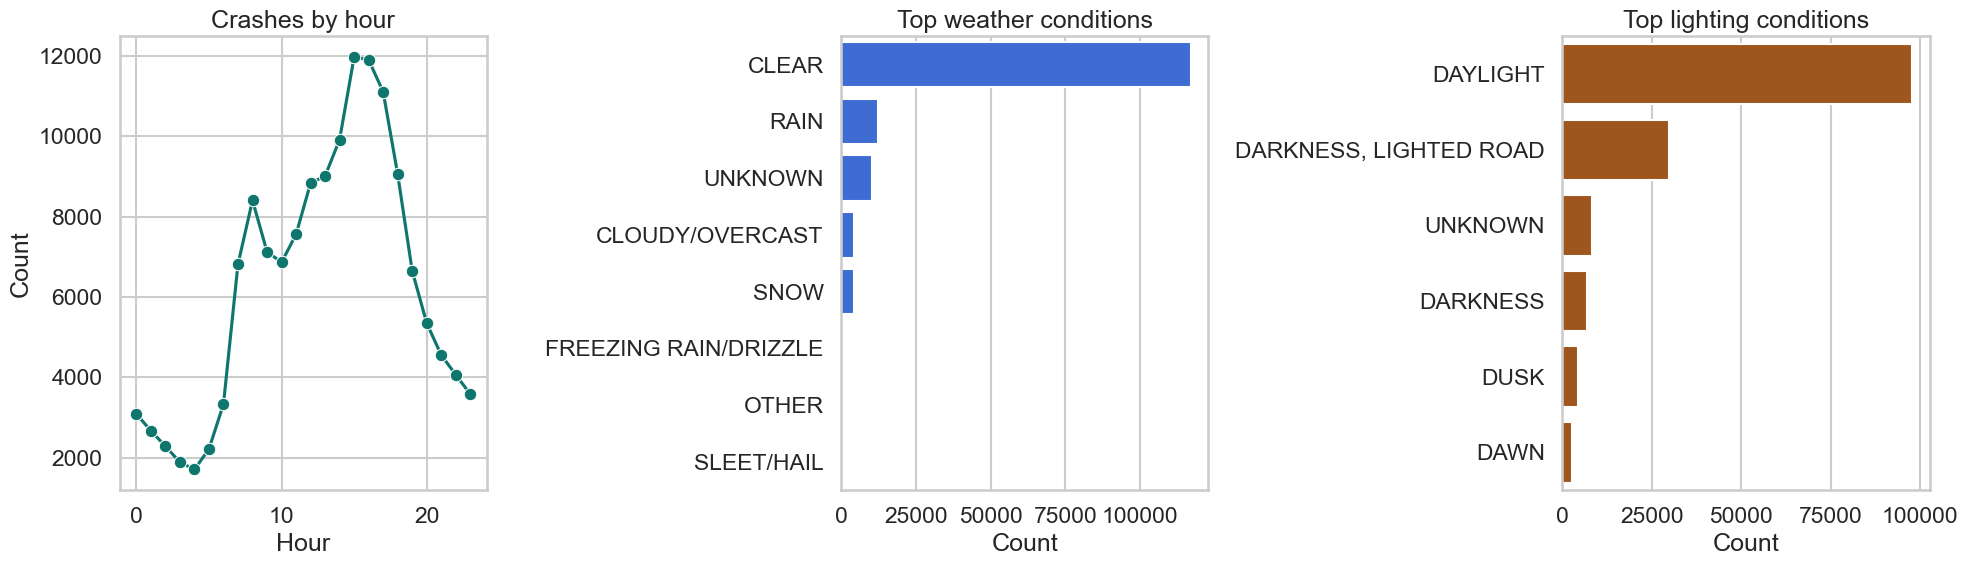

In [6]:
plot_cols = [
    "CRASH_DATE",
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
]

sample = pd.read_csv(CRASHES, usecols=plot_cols, nrows=150_000, low_memory=False)
sample["CRASH_DATE"] = pd.to_datetime(sample["CRASH_DATE"], format=CRASH_DATE_FMT, errors="coerce")
sample["hour"] = sample["CRASH_DATE"].dt.hour
sample["month"] = sample["CRASH_DATE"].dt.month

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

hour_counts = sample["hour"].value_counts().sort_index()
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker="o", ax=axes[0], color="#0f766e")
axes[0].set_title("Crashes by hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")

weather = sample["WEATHER_CONDITION"].value_counts().head(8)
sns.barplot(x=weather.values, y=weather.index, ax=axes[1], color="#2563eb")
axes[1].set_title("Top weather conditions")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

lighting = sample["LIGHTING_CONDITION"].value_counts().head(8)
sns.barplot(x=lighting.values, y=lighting.index, ax=axes[2], color="#b45309")
axes[2].set_title("Top lighting conditions")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("")

plt.tight_layout()
save_figure(fig, "crash_time_weather_lighting_overview")

print("Weather is categorical, not hourly.")
print("CRASH_HOUR / CRASH_DATE provide temporal features.")


## 4) Full-data crash density

This heatmap is aggregated from the full crash table in chunks.
It filters invalid coordinates and keeps only Chicago-like bounds so the map is not distorted by malformed points.

PosixPath('/Users/avgreensoup/Desktop/innopolis-homeworks/Project_big_mine/figures/stage2/crash_density_full_data.png')

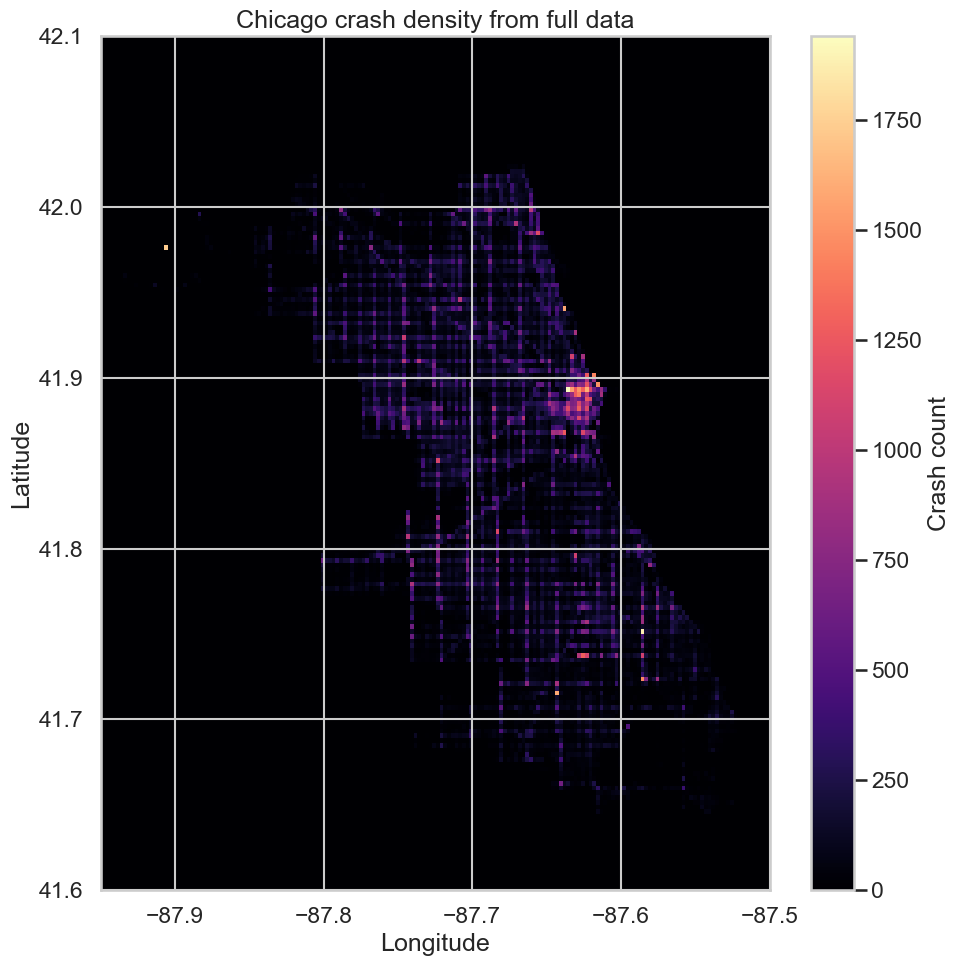

In [7]:
lat_min, lat_max = 41.60, 42.10
lon_min, lon_max = -87.95, -87.50
bins = 180
density = np.zeros((bins, bins), dtype=np.int64)

for chunk in pd.read_csv(CRASHES, usecols=["LATITUDE", "LONGITUDE"], chunksize=CHUNKSIZE, low_memory=False):
    lat = pd.to_numeric(chunk["LATITUDE"], errors="coerce")
    lon = pd.to_numeric(chunk["LONGITUDE"], errors="coerce")
    valid = lat.between(lat_min, lat_max) & lon.between(lon_min, lon_max)
    if not valid.any():
        continue
    hist, yedges, xedges = np.histogram2d(
        lat[valid],
        lon[valid],
        bins=bins,
        range=[[lat_min, lat_max], [lon_min, lon_max]],
    )
    density += hist.astype(np.int64)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(
    density,
    origin="lower",
    extent=[lon_min, lon_max, lat_min, lat_max],
    cmap="magma",
    aspect="auto",
)
ax.set_title("Chicago crash density from full data")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax, label="Crash count")
plt.tight_layout()
save_figure(fig, "crash_density_full_data")


## 5) Data quality summary

This table collects the main issues that matter for modeling and interpretation.


In [8]:
zero_coordinate_rows = count_zero_coordinates(CRASHES)
invalid_age_rows = count_invalid_age(PEOPLE)
outside_model_window_rows = count_outside_window(CRASHES, 2018, 2025)

quality_table = pd.DataFrame(
    [
        {
            "issue": "Missing or invalid geolocation",
            "affected columns": "LATITUDE, LONGITUDE",
            "frequency": (
                f"missing: {format_frequency(crash_stats['missing']['LATITUDE'], crash_stats['rows'])}; "
                f"zero coordinates: {format_frequency(zero_coordinate_rows, crash_stats['rows'])}"
            ),
            "impact": "These crashes cannot be placed reliably on the map.",
            "handling": "Invalid and zero coordinates are filtered during spatial preparation.",
        },
        {
            "issue": "UNKNOWN condition labels",
            "affected columns": "WEATHER_CONDITION, LIGHTING_CONDITION, ROADWAY_SURFACE_COND",
            "frequency": (
                f"weather: {format_frequency(crash_stats['top_values']['WEATHER_CONDITION']['UNKNOWN'], crash_stats['rows'])}; "
                f"lighting: {format_frequency(crash_stats['top_values']['LIGHTING_CONDITION']['UNKNOWN'], crash_stats['rows'])}; "
                f"surface: {format_frequency(crash_stats['top_values']['ROADWAY_SURFACE_COND']['UNKNOWN'], crash_stats['rows'])}"
            ),
            "impact": "Weakens interpretation of external-condition features.",
            "handling": "UNKNOWN is retained as an explicit category.",
        },
        {
            "issue": "Sparse vehicle speeding flag",
            "affected columns": "EXCEED_SPEED_LIMIT_I",
            "frequency": format_frequency(vehicle_stats['missing']['EXCEED_SPEED_LIMIT_I'], vehicle_stats['rows']),
            "impact": "Too sparse for reliable use as a core predictor.",
            "handling": "The field is retained only as secondary context.",
        },
        {
            "issue": "Missing and invalid ages",
            "affected columns": "AGE",
            "frequency": (
                f"missing: {format_frequency(people_stats['missing']['AGE'], people_stats['rows'])}; "
                f"invalid: {format_frequency(invalid_age_rows, people_stats['rows'])}"
            ),
            "impact": "Limits people-level demographic analysis.",
            "handling": "Missing ages are retained and invalid ages are removed during preparation.",
        },
        {
            "issue": "Uneven temporal coverage",
            "affected columns": "CRASH_DATE",
            "frequency": format_frequency(outside_model_window_rows, crash_stats['rows']),
            "impact": "Early and partial years can bias modeling.",
            "handling": "The main modeling window is restricted to 2018-2025.",
        },
        {
            "issue": "No exposure denominator",
            "affected columns": "all tables",
            "frequency": "not row-countable",
            "impact": "Prevents exact trip-level crash probability estimation.",
            "handling": "Results are presented as a relative zone-risk model.",
        },
    ]
)

display(quality_table)


,issue,affected columns,frequency,impact,handling
0,Missing or invalid geolocation,"LATITUDE, LONGITUDE","missing: 8,015 (0.77%); zero coordinates: 70 (...",These crashes cannot be placed reliably on the...,Invalid and zero coordinates are filtered duri...
1,UNKNOWN condition labels,"WEATHER_CONDITION, LIGHTING_CONDITION, ROADWAY...","weather: 63,630 (6.09%); lighting: 51,769 (4.9...",Weakens interpretation of external-condition f...,UNKNOWN is retained as an explicit category.
2,Sparse vehicle speeding flag,EXCEED_SPEED_LIMIT_I,"2,128,323 (99.89%)",Too sparse for reliable use as a core predictor.,The field is retained only as secondary context.
3,Missing and invalid ages,AGE,"missing: 664,780 (28.98%); invalid: 11 (0.00%)",Limits people-level demographic analysis.,Missing ages are retained and invalid ages are...
4,Uneven temporal coverage,CRASH_DATE,"167,132 (15.99%)",Early and partial years can bias modeling.,The main modeling window is restricted to 2018...
5,No exposure denominator,all tables,not row-countable,Prevents exact trip-level crash probability es...,Results are presented as a relative zone-risk ...


## Conclusion

This dataset is usable for a route-risk project, but only if the model is framed correctly:
- the crash table serves as the main source of pre-crash features
- vehicles and people serve as secondary tables
- post-crash outcome columns are excluded from predictors
- negative examples are created from road segments and timestamps without crashes

For route replanning, the strongest missing pieces are:
- road network geometry
- traffic volume / speed / congestion
- signal timing / stop control
- weather forecasts at prediction time
- road closures and work zones over time

For a synthetic-data setting, the project remains feasible: road segments, time, weather, and crash labels can be simulated first, and the full pipeline can be verified before moving to real exposure data.